# Stage 0 — Data Understanding for `ds006780`

this notebook is designed to give a view about dataset.
you can find the dataset here:
https://openneuro.org/datasets/ds006780/versions/1.0.0

System: BioSemi ActiveTwo, 64 channels (BioSemi64 montage)
Sampling rate: 512 Hz
Power line frequency: 60 Hz
Trigger channel: Status (BioSemi)

In [26]:

## 1. Setup

### 1.1 Imports

In [27]:

from pathlib import Path
import json
import os
import re
import warnings
from collections import Counter, defaultdict


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns


import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals, find_matching_paths


mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)


plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_palette("Set2")
print(f"MNE: {mne.__version__}")

MNE: 1.10.2


### 1.2 Paths

You have raw data on **OpenNeuro S3** and processed derivatives on **GCS**. For this notebook the cheapest, most flexible approach is:

- Read raw BIDS metadata (`participants.tsv`, `*_channels.tsv`, `*_eeg.json`) directly from S3 — those are tiny text files
- For deep-dive on a few full recordings, stage the BDF/BrainVision triplet to local `/tmp` (one at a time)
- For derivatives (filtered / ICA-cleaned `.fif` files), stage from GCS to local `/tmp`

Edit the paths below to match your machine.

In [28]:
DATASET_ID = "ds006780"

# Raw BIDS — pick ONE of these depending on what's most convenient on this machine:
#   (a) S3 (OpenNeuro public mirror, no auth) — slow per-file reads but always available
RAW_S3_BUCKET = "openneuro.org"
RAW_S3_PREFIX = DATASET_ID                                  # s3://openneuro.org/ds006780/...
RAW_LOCAL = Path.home() / "datasets" / DATASET_ID           # set to None if you don't have it
RAW_GCS_BUCKET = None                                       # e.g. "my-asd-eeg-raw"
RAW_GCS_PREFIX = DATASET_ID

# Derivatives — your processed outputs (post-preprocess, post-ICA)
DERIV_GCS_BUCKET = "REPLACE_ME_with_your_bucket"
DERIV_GCS_PREFIX = "ds006780_derivatives"

# Local scratch for staging
SCRATCH = Path("/tmp") / "eeg_scratch"
SCRATCH.mkdir(parents=True, exist_ok=True)

# Pick the raw root we'll actually use for BIDS reading
if RAW_LOCAL and RAW_LOCAL.exists():
    BIDS_ROOT = RAW_LOCAL
    print(f"Using local raw at {BIDS_ROOT}")
else:
    BIDS_ROOT = None  # we'll use S3 helper functions instead
    print(f"No local raw — will read metadata from s3://{RAW_S3_BUCKET}/{RAW_S3_PREFIX}/ via boto3")

No local raw — will read metadata from s3://openneuro.org/ds006780/ via boto3


### 1.3 Helper: read text files from S3 without downloading the dataset

For metadata-only operations (TSVs and JSONs), `boto3` with `--no-sign-request` is enough. Skip this cell if you set `BIDS_ROOT` to a local path.

In [29]:
# Optional helpers — only used if BIDS_ROOT is None
try:
    import boto3
    from botocore import UNSIGNED
    from botocore.config import Config

    s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    def s3_get_text(key: str) -> str:
        # Fetch a small text file from the OpenNeuro public mirror.
        obj = s3.get_object(Bucket=RAW_S3_BUCKET, Key=f"{RAW_S3_PREFIX}/{key}")
        return obj["Body"].read().decode("utf-8")

    def s3_list(prefix: str = ""):
        # List keys under a sub-prefix.
        paginator = s3.get_paginator("list_objects_v2")
        full_prefix = f"{RAW_S3_PREFIX}/{prefix}".rstrip("/")
        out = []
        for page in paginator.paginate(Bucket=RAW_S3_BUCKET, Prefix=full_prefix):
            for obj in page.get("Contents", []):
                out.append(obj["Key"])
        return out

    print("S3 helpers ready (no AWS auth required for OpenNeuro).")
except ImportError:
    print("boto3 not installed — install with: pip install boto3")
    print("Or set BIDS_ROOT to a local path.")

S3 helpers ready (no AWS auth required for OpenNeuro).


---

## 2. Dataset identity card

Every BIDS dataset has two metadata files at the root: `dataset_description.json` (machine-readable) and `README` (human-readable). These are the authoritative source for "what is this?".

In [30]:
def read_root_text(rel_path: str) -> str:
    if BIDS_ROOT is not None:
        p = BIDS_ROOT / rel_path
        return p.read_text() if p.exists() else ""
    return s3_get_text(rel_path)

print("=== dataset_description.json ===")
desc = json.loads(read_root_text("dataset_description.json"))
print(json.dumps(desc, indent=2))

print("\n=== README ===")
readme = read_root_text("README")
print(readme[:4000])  # first 4000 chars; full README may be longer

=== dataset_description.json ===
{
  "Name": "SFARI_EEG multi-paradigm dataset (BIDS)",
  "BIDSVersion": "1.9.0",
  "DatasetType": "raw",
  "License": "CC0",
  "Authors": [
    "Sophie Molholm, Theo Vanneau, John J. Foxe"
  ],
  "HowToAcknowledge": "Please cite the paper in relation with the data you are working with",
  "Funding": [
    "This work was supported by a grant from the Simons Foundation Autism Research Initiative (SFARI Award # 874845, SM).  Support for recruitment and phenotyping of participants was provided by the Human Clinical Phenotyping Core of the NICHD funded Rose. F. Kennedy Intellectual and Developmental Disabilities Research Center (P50  HD105352, SM)"
  ],
  "ReferencesAndLinks": [],
  "EthicsApprovals": [
    "All procedures were approved by the Institutional Review Board of the Albert Einstein College of Medicine and adhered to tenets for human subjects\u2019 research laid out in the Declaration of Helsinki. All participants assented to the procedures and par

**What you should pull out of the README**, from prior investigation in this project:

- **Population:** children (~6–17 years), with diagnosed ASD and a typically developing (TD) control group.
- **Hardware:** BioSemi ActiveTwo, 64 scalp channels (BioSemi64 montage) + 8 EXG channels + a Status trigger channel.
- **Sampling rate:** 512 Hz native (some files may be different — verify in §5).
- **Reference:** BioSemi uses CMS/DRL active reference; you'll typically re-reference to average for connectivity.
- **EXG layout:** ambiguous in the README. Empirically, **EXG1–4 carry signal (likely mastoids)** and **EXG5–8 are flat (disconnected)**. We confirmed this in earlier sessions and even drafted an email to the data collectors. Treat as `misc` until they confirm otherwise.
- **Paradigms (7 total):** Resting-state, FAST (face attention), IC (illusory contours), AVSRT (audio-visual reaction time), Beep-Flash (attentional switching), motor (treadmill walk + visual fixation), ASSR (auditory steady-state, 27 / 40 Hz).

The relevant lab-published paper for the ASSR paradigm is Darrell et al., 2025 (bioRxiv 2025.08.05.668742) — see if its preprocessing pipeline gives you ideas you can borrow.

---

## 3. Participants and groups

`participants.tsv` is the table you should look at *before* any signal processing. It tells you:

- How many subjects total
- Class balance (ASD vs control) — critical for any classifier
- Demographics (age, sex) — confounds you'll need to handle

In [31]:
participants = pd.read_csv(
    Path(BIDS_ROOT, "participants.tsv") if BIDS_ROOT else None,
    sep="\t",
) if BIDS_ROOT else pd.read_csv(
    pd.io.common.StringIO(s3_get_text("participants.tsv")),
    sep="\t",
)

print(f"Total participants: {len(participants)}")
print(f"Columns: {list(participants.columns)}")
participants.head()

Total participants: 136
Columns: ['participant_id', 'age', 'sex', 'group', 'handedness', 'completed_ASSR', 'completed_AVSRT', 'completed_Beep-Flash', 'completed_FAST', 'completed_Illusory_contours', 'completed_Motor', 'completed_Resting_state', 'fsiq', 'srs2_total_t', 'mabc_total_ss', 'cpt_response_style', 'ados_css', 'medication', 'fsiq_dup', 'srs2_total_t_dup', 'mabc_total_ss_dup', 'cpt_response_style_dup', 'ados_css_dup', 'medication_dup']


,participant_id,age,sex,group,handedness,completed_ASSR,completed_AVSRT,completed_Beep-Flash,completed_FAST,completed_Illusory_contours,...,mabc_total_ss,cpt_response_style,ados_css,medication,fsiq_dup,srs2_total_t_dup,mabc_total_ss_dup,cpt_response_style_dup,ados_css_dup,medication_dup
0,sub-10025,8.3,m,TD,L,yes,yes,yes,yes,yes,...,5.0,74,NaN,No,121.0,44.0,5.0,74,NaN,No
1,sub-10036,11.0,m,TD,R,yes,yes,yes,yes,yes,...,8.0,40,NaN,No,85.0,48.0,8.0,40,NaN,No
2,sub-10129,12.7,f,TD,R,yes,yes,yes,yes,yes,...,8.0,38,NaN,No,115.0,54.0,8.0,38,NaN,No
3,sub-10170,8.3,f,TD,R,yes,yes,yes,yes,yes,...,6.0,42,NaN,No,94.0,60.0,6.0,42,NaN,No
4,sub-10177,8.1,m,TD,R,yes,yes,yes,yes,yes,...,8.0,65,NaN,No,118.0,47.0,8.0,65,NaN,No


In [32]:
# Look for the diagnostic group column. Typical names: 'group', 'diagnosis', 'asd_status'.
candidate_group_cols = [c for c in participants.columns
                        if any(k in c.lower() for k in
                               ("group", "diag", "asd", "status", "condition"))]
print("Candidate group columns:", candidate_group_cols)
GROUP_COL = candidate_group_cols[0] if candidate_group_cols else None
print(f"Using GROUP_COL = {GROUP_COL!r}")

if GROUP_COL:
    print(participants[GROUP_COL].value_counts(dropna=False))

Candidate group columns: ['group']
Using GROUP_COL = 'group'
group
ASD            66
TD             41
ASD SIBLING    28
NAN             1
Name: count, dtype: int64


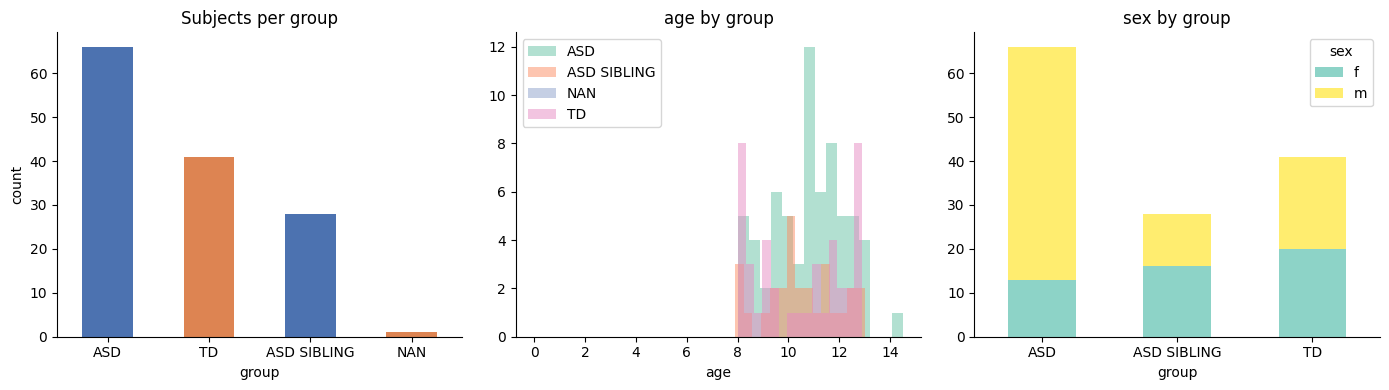

In [33]:
# Visualize group balance and demographics
if GROUP_COL:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Group counts
    participants[GROUP_COL].value_counts().plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"])
    axes[0].set_title("Subjects per group")
    axes[0].set_ylabel("count")
    axes[0].tick_params(axis="x", rotation=0)

    # Age distribution by group (if available)
    age_col = next((c for c in participants.columns if "age" in c.lower()), None)
    if age_col:
        for g, df in participants.groupby(GROUP_COL):
            axes[1].hist(df[age_col].dropna(), alpha=0.5, label=str(g), bins=15)
        axes[1].set_title(f"{age_col} by group")
        axes[1].set_xlabel(age_col); axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "no age column", ha="center"); axes[1].axis("off")

    # Sex distribution by group
    sex_col = next((c for c in participants.columns if "sex" in c.lower() or "gender" in c.lower()), None)
    if sex_col:
        ct = pd.crosstab(participants[GROUP_COL], participants[sex_col])
        ct.plot.bar(stacked=True, ax=axes[2], colormap="Set3")
        axes[2].set_title(f"{sex_col} by group")
        axes[2].tick_params(axis="x", rotation=0)
    else:
        axes[2].text(0.5, 0.5, "no sex column", ha="center"); axes[2].axis("off")

    plt.tight_layout(); plt.show()
else:
    print("Could not auto-detect group column — inspect participants.head() above and set GROUP_COL manually.")

---

## 4. Tasks and paradigms

There are seven paradigms in this dataset, but not every subject has every task. Build the task × subject matrix to see coverage.

In [34]:
if BIDS_ROOT:
    subjects = get_entity_vals(BIDS_ROOT, "subject")
    tasks = get_entity_vals(BIDS_ROOT, "task")
    print(f"{len(subjects)} subjects, {len(tasks)} tasks: {tasks}")
else:
    # Build from S3 listing — slower but works without a local copy
    keys = s3_list()
    pat = re.compile(r"sub-([^/_]+).+task-([^/_]+)")
    subj_task = set()
    for k in keys:
        if "/eeg/" not in k:
            continue
        m = pat.search(k)
        if m:
            subj_task.add(m.groups())
    subjects = sorted({s for s, _ in subj_task})
    tasks    = sorted({t for _, t in subj_task})
    print(f"{len(subjects)} subjects, {len(tasks)} tasks: {tasks}")

139 subjects, 7 tasks: ['ASSR', 'AVSRT', 'Beepflash', 'FAST', 'IC', 'Restingstate', 'motor']


In [35]:
# Coverage matrix: subjects × tasks
if BIDS_ROOT:
    coverage = pd.DataFrame(0, index=subjects, columns=tasks)
    for sub in subjects:
        for task in tasks:
            paths = find_matching_paths(BIDS_ROOT, subjects=sub, tasks=task,
                                        datatypes="eeg", suffixes="eeg",
                                        extensions=[".bdf", ".vhdr", ".edf"])
            coverage.loc[sub, task] = len(paths)
else:
    coverage = pd.DataFrame(0, index=subjects, columns=tasks)
    for s, t in subj_task:
        coverage.loc[s, t] += 1  # rough — not file-accurate but gives presence

# Top-level summary
print("Recordings per task:")
print(coverage.sum().sort_values(ascending=False))
print(f"\nTotal recordings: {coverage.values.sum()}")
print(f"Subjects with all {len(tasks)} tasks: {(coverage > 0).all(axis=1).sum()}")

Recordings per task:
FAST            131
Restingstate    131
IC              127
motor           124
ASSR            123
AVSRT           121
Beepflash       119
dtype: int64

Total recordings: 876
Subjects with all 7 tasks: 104


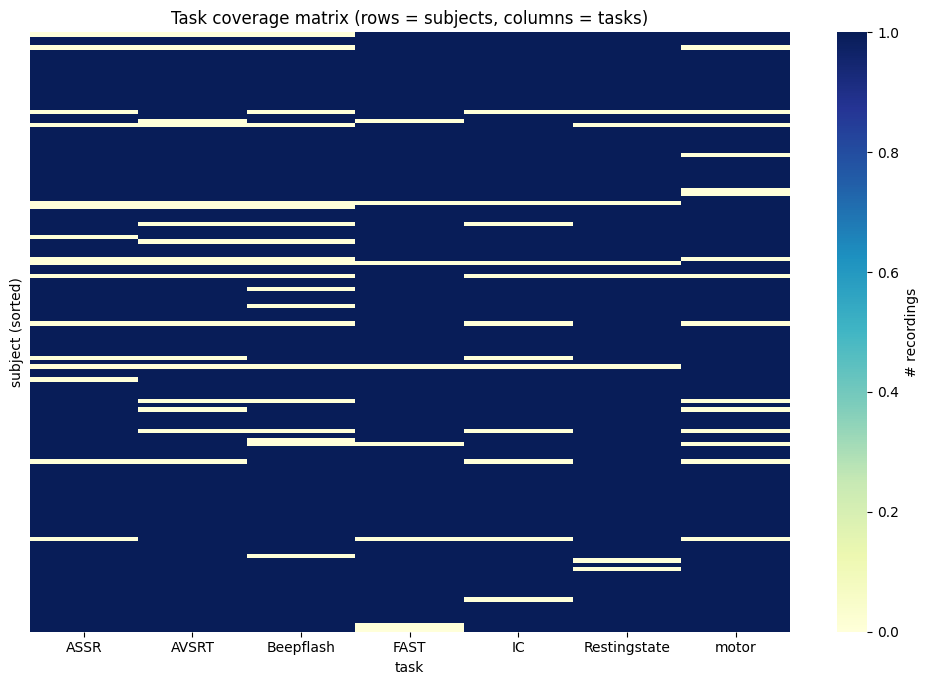

In [36]:
# Visualize coverage as a heatmap (subjects clustered by missing-task pattern)
fig, ax = plt.subplots(figsize=(10, max(6, len(subjects) * 0.05)))
sns.heatmap(coverage.astype(int), cmap="YlGnBu",
            cbar_kws={"label": "# recordings"}, ax=ax,
            yticklabels=False)
ax.set_title("Task coverage matrix (rows = subjects, columns = tasks)")
ax.set_xlabel("task"); ax.set_ylabel("subject (sorted)")
plt.tight_layout(); plt.show()

**Brief paradigm guide** — what each task probes and what features matter:

| Task | What it probes | Key features for ASD |
|---|---|---|
| **Restingstate** | Spontaneous oscillations, default-mode activity | Alpha peak frequency & power, theta/beta ratio, functional connectivity |
| **FAST** | Face / attention selectivity | N170 ERP amplitude, face-selective gamma |
| **IC** | Illusory contour completion (visual binding) | Gamma-band activity, NCl (negativity for closure) |
| **AVSRT** | Multisensory integration | Audiovisual integration windows, P50 / P100 amplitudes |
| **Beep-Flash** | Attentional switching | Attention-modulated alpha, frontal-parietal connectivity |
| **motor** | Sensorimotor + walking | Mu rhythm desync, beta-band motor cortex modulation |
| **ASSR** | Auditory steady-state response | 40 Hz coherence/PLV, gamma-band entrainment — *strong ASD literature* |

For your GNN+PLV plan, **Restingstate and ASSR are the highest-yield starting points**. Resting state because the connectivity literature is well-established; ASSR because it's the paradigm the data collectors themselves published on, and gamma-band PLV at 40 Hz is a known ASD marker.

---

## 5. Recording-level metadata audit

For every recording, BIDS provides a `*_eeg.json` sidecar with sampling rate, duration, reference info, etc. Sample 30–50 recordings across tasks and look for inconsistencies. You **will** find some.

In [37]:
def collect_sidecar(bids_path: BIDSPath) -> dict:
    # Read the JSON sidecar for a recording and return a dict of key fields.
    sidecar = bids_path.copy().update(suffix="eeg", extension=".json")
    if not sidecar.fpath.exists():
        return {}
    info = json.loads(sidecar.fpath.read_text())
    return {
        "subject": bids_path.subject,
        "task": bids_path.task,
        "run": bids_path.run,
        "sfreq": info.get("SamplingFrequency"),
        "duration_s": info.get("RecordingDuration"),
        "n_eeg": info.get("EEGChannelCount"),
        "n_eog": info.get("EOGChannelCount"),
        "n_emg": info.get("EMGChannelCount"),
        "n_misc": info.get("MiscChannelCount"),
        "reference": info.get("EEGReference"),
        "powerline": info.get("PowerLineFrequency"),
        "manufacturer": info.get("Manufacturer"),
        "software_filters": info.get("SoftwareFilters"),
    }

if BIDS_ROOT:
    # Sample up to 5 subjects per task for a quick audit
    audit_paths = []
    for task in tasks:
        per_task = find_matching_paths(BIDS_ROOT, tasks=task, datatypes="eeg",
                                       suffixes="eeg",
                                       extensions=[".bdf", ".vhdr", ".edf"])
        audit_paths.extend(per_task[:5])
    print(f"Auditing {len(audit_paths)} recordings...")
    audit_rows = [collect_sidecar(bp) for bp in audit_paths]
    audit_df = pd.DataFrame(audit_rows)
    audit_df.head(20)
else:
    print("Set BIDS_ROOT to a local path to run the metadata audit.")
    audit_df = pd.DataFrame()

Set BIDS_ROOT to a local path to run the metadata audit.


In [38]:
# Quick consistency checks
if not audit_df.empty:
    print("=== Sampling rate distribution per task ===")
    print(audit_df.groupby("task")["sfreq"].describe()[["count", "min", "max"]])
    print("\n=== Reference scheme ===")
    print(audit_df["reference"].value_counts(dropna=False))
    print("\n=== Recording duration (s) per task ===")
    print(audit_df.groupby("task")["duration_s"].describe()[["count", "mean", "min", "max"]])
    print("\n=== Channel counts (EEG / EOG / EMG / MISC) per task ===")
    print(audit_df.groupby("task")[["n_eeg", "n_eog", "n_emg", "n_misc"]].mean().round(1))

In [39]:
# Visualize duration distribution per task
if not audit_df.empty and "duration_s" in audit_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=audit_df.dropna(subset=["duration_s"]),
                x="task", y="duration_s", ax=ax)
    ax.set_yscale("log")
    ax.set_title("Recording duration by task (log scale)")
    ax.set_ylabel("seconds (log)")
    plt.xticks(rotation=30); plt.tight_layout(); plt.show()

---

## 6. Channel configuration and montage

The BioSemi64 montage is well-supported in MNE. Visualizing the 2D and 3D layout helps you reason about connectivity — for the GNN, the spatial positions are what give your "graph" its geometry.

In [40]:
# Inspect channels.tsv for one recording
if BIDS_ROOT and tasks:
    sample_path = find_matching_paths(BIDS_ROOT, tasks=tasks[0],
                                      datatypes="eeg", suffixes="eeg",
                                      extensions=[".bdf", ".vhdr", ".edf"])[0]
    ch_path = sample_path.copy().update(suffix="channels", extension=".tsv")
    ch_df = pd.read_csv(ch_path.fpath, sep="\t")
    print(f"Channels in {sample_path.basename}:")
    print(ch_df["type"].value_counts())
    print()
    ch_df.head(15)

/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_67730/4076042927.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


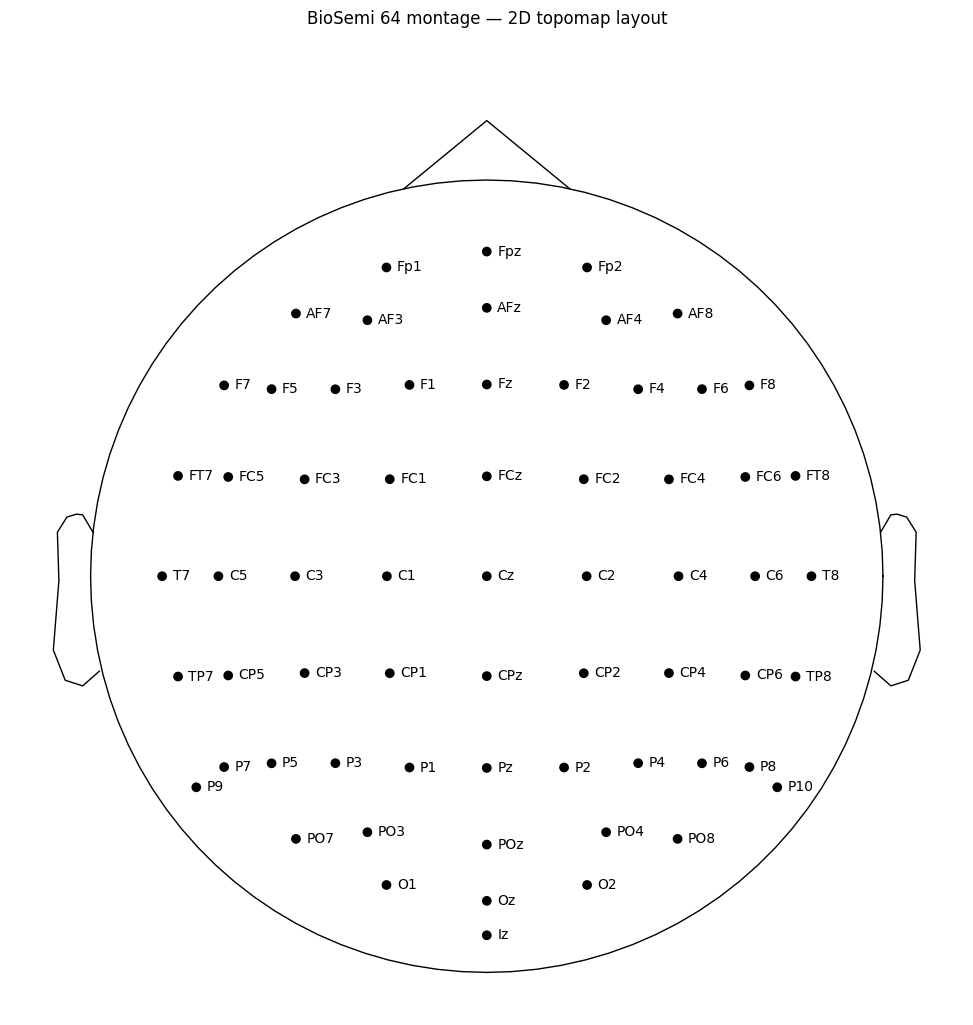

/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_67730/4076042927.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


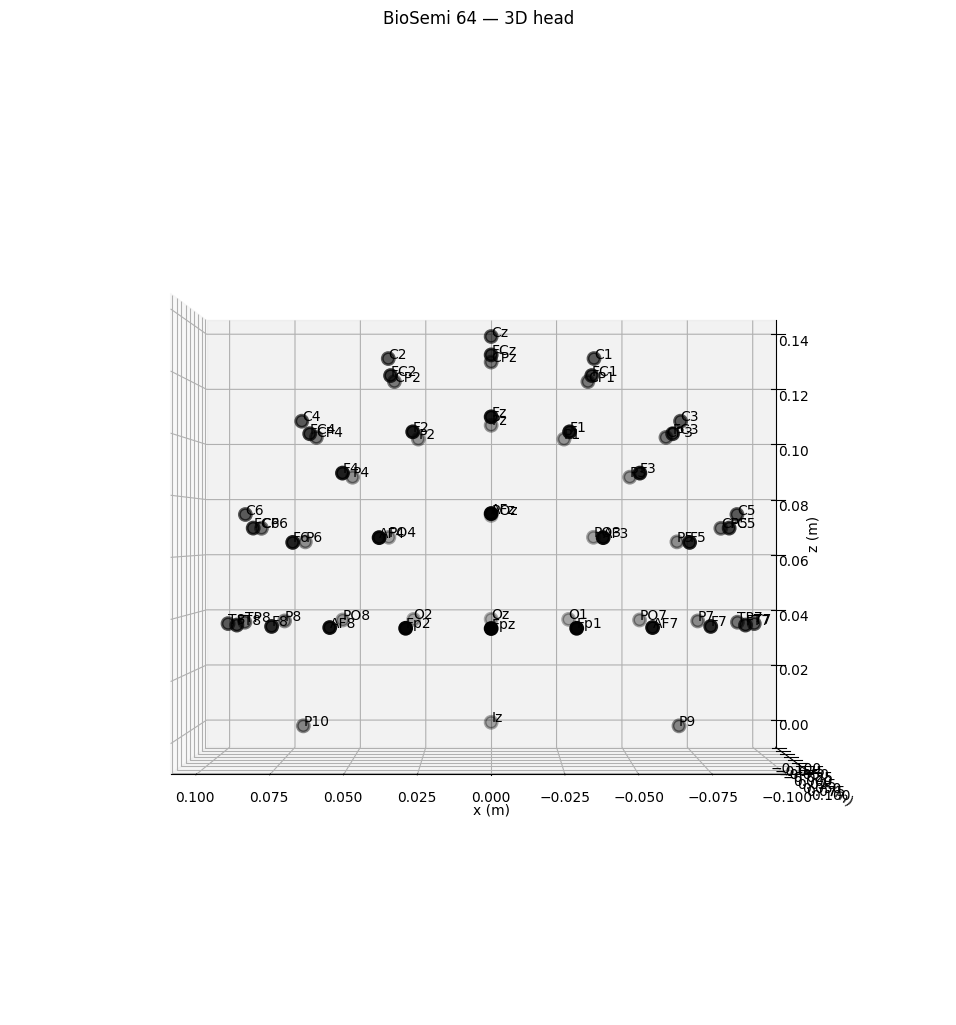

In [41]:
# Standard BioSemi64 montage — visualize
montage = mne.channels.make_standard_montage("biosemi64")
fig = montage.plot(kind="topomap", show_names=True, show=False)
fig.suptitle("BioSemi 64 montage — 2D topomap layout", y=1.02)
plt.tight_layout(); plt.show()

# 3D view — useful for thinking about graph edges
fig = montage.plot(kind="3d", show=False)
fig.suptitle("BioSemi 64 — 3D head", y=1.02)
plt.tight_layout(); plt.show()

---

## 7. Single recording deep dive

Pick one ASD subject and one TD subject from the same task (Restingstate is cleanest). Walk through the full visualization stack: time series → PSD → topomap → spectrogram. This gives you intuition for what "normal" looks like in this data.

In [42]:
# Helper: stage one recording from S3 to /tmp if we don't have local
def get_local_path(bids_path: BIDSPath) -> BIDSPath:
    # Return a BIDSPath that points to a local copy of the recording.
    if BIDS_ROOT:
        return bids_path
    # Stage from S3 — for BDF we just need the .bdf file plus channels/events
    ext = bids_path.extension or ".bdf"
    rel = str(bids_path.fpath).split(f"{RAW_S3_PREFIX}/")[-1] if False else None
    # Rebuild relative key from BIDSPath fields
    rel_key = (f"sub-{bids_path.subject}/eeg/"
               f"sub-{bids_path.subject}_task-{bids_path.task}_eeg{ext}")
    if bids_path.run:
        rel_key = (f"sub-{bids_path.subject}/eeg/"
                   f"sub-{bids_path.subject}_task-{bids_path.task}_run-{bids_path.run}_eeg{ext}")
    raise NotImplementedError(
        "Staging from S3 is implemented in your existing pipeline (`staged_from_s3`). "
        "Reuse it here, or set RAW_LOCAL to a synced copy of the dataset."
    )

# Pick one subject — change this to whatever you want to inspect
sample_subject = subjects[0] if subjects else None
sample_task = "Restingstate" if "Restingstate" in tasks else (tasks[0] if tasks else None)
print(f"Sample subject: {sample_subject}, task: {sample_task}")

Sample subject: 10003, task: Restingstate


In [43]:
# Load one Restingstate recording
if BIDS_ROOT and sample_subject and sample_task:
    paths = find_matching_paths(BIDS_ROOT, subjects=sample_subject, tasks=sample_task,
                                datatypes="eeg", suffixes="eeg",
                                extensions=[".bdf", ".vhdr", ".edf"])
    if paths:
        bp = paths[0]
        raw = read_raw_bids(bp, verbose=False)
        raw.load_data()
        # Quick clean: keep EEG only for visualization
        raw.pick("eeg")
        # Apply standard montage if not present
        try:
            raw.set_montage("biosemi64", on_missing="ignore")
        except Exception:
            pass
        print(raw.info)
        print(f"\nDuration: {raw.times[-1]:.1f} s, channels: {len(raw.ch_names)}, sfreq: {raw.info['sfreq']} Hz")

In [44]:
# 7.1 Time series — first 10 seconds, subset of channels
if "raw" in dir():
    pick_chans = [c for c in ["Fp1", "Fz", "Cz", "Pz", "O1", "C3", "C4"] if c in raw.ch_names]
    fig = raw.copy().pick(pick_chans).plot(
        duration=10, n_channels=len(pick_chans), scalings={"eeg": 80e-6},
        title=f"{sample_subject} — {sample_task} — first 10 s",
        show=False, block=False,
    )
    plt.show()

In [45]:
# 7.2 Power spectral density (PSD) — average across channels
if "raw" in dir():
    psd = raw.compute_psd(method="welch", fmin=1, fmax=45, n_fft=int(raw.info["sfreq"] * 4))
    fig, ax = plt.subplots(figsize=(10, 4))
    psd.plot(axes=ax, show=False)
    ax.set_title(f"PSD — {sample_subject} — {sample_task}")
    plt.tight_layout(); plt.show()

In [46]:
# 7.3 Topomaps of band power
BANDS = {
    "delta (1-4)": (1, 4),
    "theta (4-8)": (4, 8),
    "alpha (8-13)": (8, 13),
    "beta (13-30)": (13, 30),
    "gamma (30-45)": (30, 45),
}

if "raw" in dir():
    psd = raw.compute_psd(fmin=1, fmax=45, n_fft=int(raw.info["sfreq"] * 4))
    fig, axes = plt.subplots(1, len(BANDS), figsize=(4 * len(BANDS), 3.5))
    for ax, (name, (lo, hi)) in zip(axes, BANDS.items()):
        psd.plot_topomap(bands={name: (lo, hi)}, axes=ax, show=False, normalize=False)
    fig.suptitle(f"Band power topomaps — {sample_subject} — {sample_task}")
    plt.tight_layout(); plt.show()

In [47]:
# 7.4 Spectrogram (time-frequency) for a single channel
if "raw" in dir():
    target_ch = "Cz" if "Cz" in raw.ch_names else raw.ch_names[0]
    data = raw.copy().pick([target_ch]).get_data()[0] * 1e6  # to µV
    sfreq = raw.info["sfreq"]
    from scipy.signal import spectrogram
    f, t, Sxx = spectrogram(data, fs=sfreq, nperseg=int(sfreq * 2),
                            noverlap=int(sfreq * 1.5))
    mask = f <= 45
    fig, ax = plt.subplots(figsize=(11, 4))
    pcm = ax.pcolormesh(t, f[mask], 10 * np.log10(Sxx[mask] + 1e-20),
                        cmap="viridis", shading="auto")
    ax.set_ylabel("Freq (Hz)"); ax.set_xlabel("Time (s)")
    ax.set_title(f"Spectrogram — {target_ch} — {sample_subject} — {sample_task}")
    plt.colorbar(pcm, label="Power (dB)")
    plt.tight_layout(); plt.show()

---

## 7.5 Group-level glance — random samples and average PSD

Before doing the full band-power comparison across subjects (§8), it's worth just *looking*. Pull 3 random recordings from each group on the same task (Restingstate), eyeball the raw traces side-by-side, and overlay the group-averaged PSDs.

You're not testing anything here — this is the equivalent of squinting at the data to make sure it looks like brain. Six recordings won't reveal a group effect even if one is there. What it *will* reveal is gross failures: flat channels nobody caught, a recording that's mostly muscle, a sampling-rate mismatch that slipped past §5. Spot those before §8 invests compute in a wider sample.


In [48]:
# 7.5 — Pick 3 random subjects per group, stage from S3, load + compute PSD
import shutil
import random
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# S3 client (re-init in case this cell runs before §8 has set it up)
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
SCRATCH = Path("/tmp/eeg_scratch"); SCRATCH.mkdir(parents=True, exist_ok=True)
RAW_S3_BUCKET = "openneuro.org"
RAW_S3_PREFIX = "ds006780"

N_PER_GROUP = 3
TARGET_TASK = "Restingstate" if "Restingstate" in tasks else tasks[0]
SEED = 42  # change to resample
random.seed(SEED)
print(f"Target task: {TARGET_TASK}, seed: {SEED}")

# Normalize participant IDs to BIDS form ("sub-XXX" → "XXX")
pid_col = next((c for c in participants.columns
                if c.lower() in ("participant_id", "participantid", "subject", "sub")),
               participants.columns[0])
def _norm(x):
    s = str(x).strip()
    return s[4:] if s.startswith("sub-") else s

participants_norm = participants.copy()
participants_norm["_sub_id"] = participants_norm[pid_col].apply(_norm)
bids_subjects_norm = {_norm(s) for s in subjects}

# Restrict to subjects who actually have the target task (if §4 ran)
try:
    have_task = set(coverage.index[coverage[TARGET_TASK] > 0])
except (NameError, KeyError):
    have_task = bids_subjects_norm

def stage_from_s3(sub: str, task: str):
    """Download EEG file + sidecars for (sub, task). Returns local Path or None."""
    rel_dir = f"sub-{sub}/eeg"
    base = f"sub-{sub}_task-{task}"
    local_dir = SCRATCH / rel_dir
    local_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{RAW_S3_PREFIX}/{rel_dir}/{base}"
    try:
        resp = s3.list_objects_v2(Bucket=RAW_S3_BUCKET, Prefix=prefix)
    except Exception as e:
        print(f"    S3 list failed: {e}")
        return None
    keys = [obj["Key"] for obj in resp.get("Contents", [])]
    if not keys:
        return None
    eeg_local = None
    for key in keys:
        fname = key.split("/")[-1]
        local_path = local_dir / fname
        if not local_path.exists():
            try:
                s3.download_file(RAW_S3_BUCKET, key, str(local_path))
            except Exception as e:
                print(f"    download {fname} failed: {e}")
                continue
        if fname.endswith(".bdf") or fname.endswith(".vhdr"):
            eeg_local = local_path
    return eeg_local

# Sample 3 random subjects per group from those available in BIDS + have the task
sample_picks = {}  # {group: [sub_id, ...]}
for grp_name, grp_df in participants_norm.groupby(GROUP_COL):
    available = [s for s in grp_df["_sub_id"]
                 if s in bids_subjects_norm and s in have_task]
    if len(available) < N_PER_GROUP:
        print(f"[{grp_name}] only {len(available)} available with task {TARGET_TASK}, using all")
        sample_picks[str(grp_name)] = available
    else:
        sample_picks[str(grp_name)] = random.sample(available, N_PER_GROUP)
    print(f"[{grp_name}] picked: {sample_picks[str(grp_name)]}")

# Load each, filter, store the raw object + PSD
group_data = {grp: [] for grp in sample_picks}
for grp, sub_list in sample_picks.items():
    print(f"\n[{grp}] loading...")
    for i, sub in enumerate(sub_list, 1):
        local_eeg = stage_from_s3(sub, TARGET_TASK)
        if local_eeg is None:
            print(f"  [{i}/{len(sub_list)}] sub-{sub}: not found, skip")
            continue
        try:
            if local_eeg.suffix == ".bdf":
                raw_i = mne.io.read_raw_bdf(str(local_eeg), preload=True, verbose=False)
            else:
                raw_i = mne.io.read_raw_brainvision(str(local_eeg), preload=True, verbose=False)
            raw_i.pick("eeg")
            raw_i.filter(1, 45, verbose=False)
            try:
                raw_i.set_montage("biosemi64", on_missing="ignore")
            except Exception:
                pass
            psd_obj = raw_i.compute_psd(method="welch", fmin=1, fmax=45,
                                        n_fft=int(raw_i.info["sfreq"] * 4),
                                        verbose=False)
            group_data[grp].append({
                "sub": sub,
                "raw": raw_i,                          # preloaded into memory
                "freqs": psd_obj.freqs,
                "psd_per_chan": psd_obj.get_data(),    # (n_chans, n_freqs)
            })
            print(f"  [{i}/{len(sub_list)}] sub-{sub}: ok "
                  f"(sfreq={raw_i.info['sfreq']:.0f}Hz, "
                  f"{len(raw_i.ch_names)} ch, {raw_i.times[-1]:.0f}s)")
        except Exception as e:
            print(f"  [{i}/{len(sub_list)}] sub-{sub}: FAIL — {type(e).__name__}: {e}")

n_loaded = sum(len(v) for v in group_data.values())
print(f"\nLoaded {n_loaded} recordings total across {len(group_data)} groups")


Target task: Restingstate, seed: 42
[ASD] picked: ['11674', '11152', '11038']
[ASD SIBLING] picked: ['1593', '1536', '1530']
[NAN] only 1 available with task Restingstate, using all
[NAN] picked: ['11814']
[TD] picked: ['10400', '10214', '10212']

[ASD] loading...
  [1/3] sub-11674: ok (sfreq=512Hz, 72 ch, 62s)
  [2/3] sub-11152: ok (sfreq=512Hz, 72 ch, 63s)
  [3/3] sub-11038: ok (sfreq=512Hz, 72 ch, 63s)

[ASD SIBLING] loading...
  [1/3] sub-1593: ok (sfreq=512Hz, 72 ch, 62s)
  [2/3] sub-1536: ok (sfreq=512Hz, 72 ch, 63s)
  [3/3] sub-1530: ok (sfreq=512Hz, 72 ch, 63s)

[NAN] loading...
  [1/1] sub-11814: ok (sfreq=512Hz, 72 ch, 63s)

[TD] loading...
  [1/3] sub-10400: ok (sfreq=512Hz, 72 ch, 63s)
  [2/3] sub-10214: ok (sfreq=512Hz, 72 ch, 62s)
  [3/3] sub-10212: ok (sfreq=512Hz, 72 ch, 153s)

Loaded 10 recordings total across 4 groups


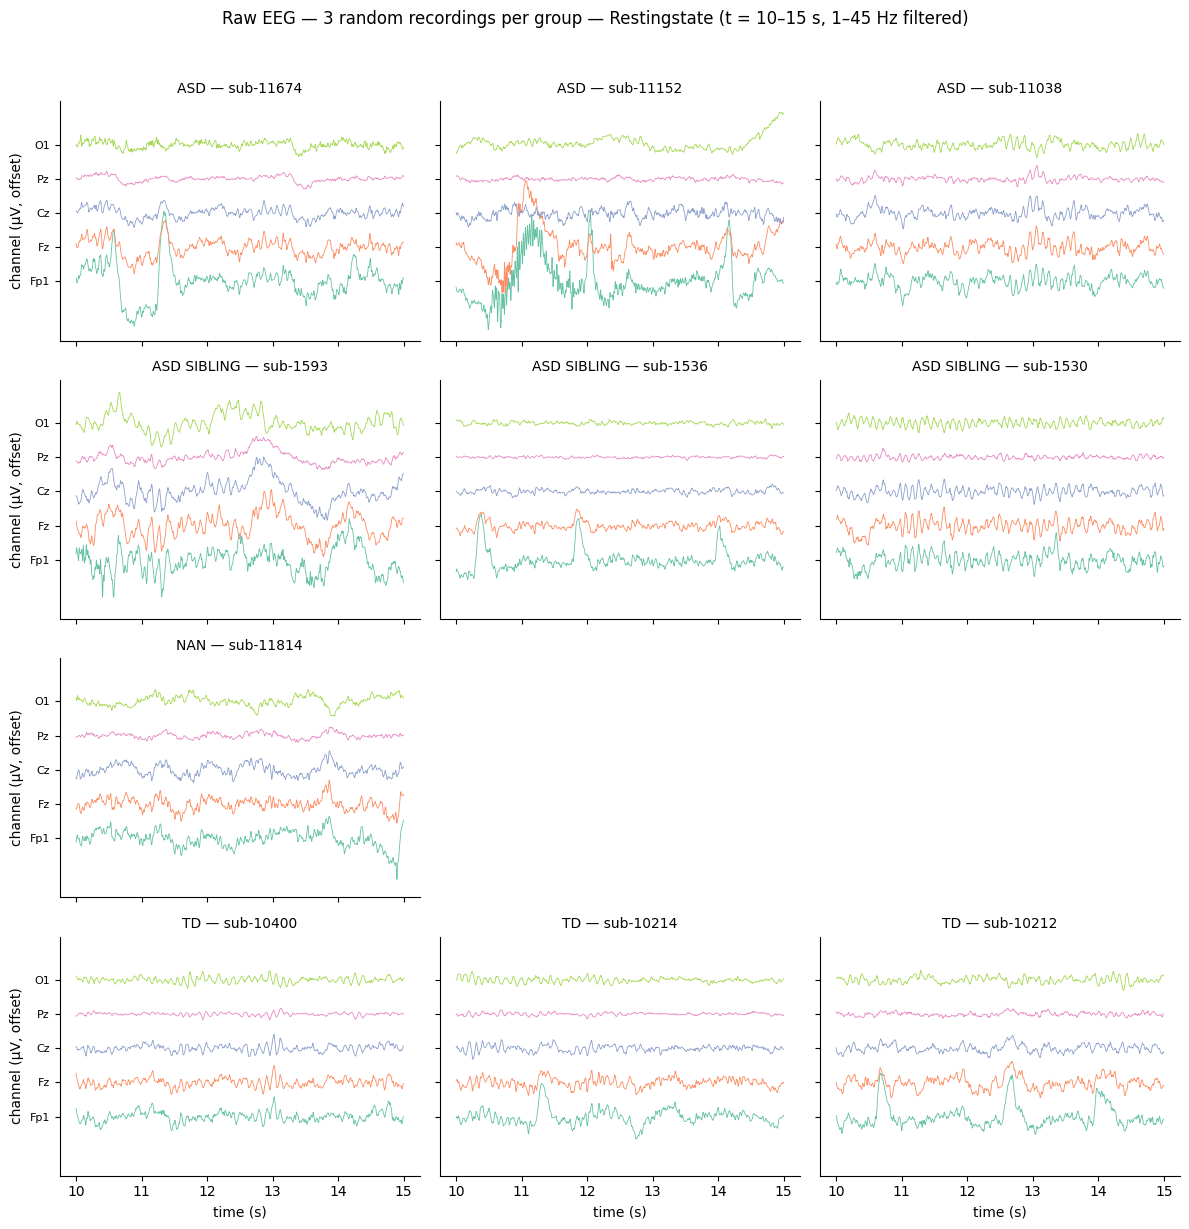

In [49]:
# 7.5 — Raw time-series grid (groups × recordings)
DISPLAY_CHANS = ["Fp1", "Fz", "Cz", "Pz", "O1"]   # frontal → occipital
START_T = 10.0     # skip first 10 s (often noisy at recording start)
WIN_S   = 5.0      # show 5 s

if not any(group_data.values()):
    print("No recordings loaded — see the load cell output above.")
else:
    groups = list(group_data.keys())
    n_groups = len(groups)
    n_per = max(len(v) for v in group_data.values())

    fig, axes = plt.subplots(n_groups, n_per,
                             figsize=(4 * n_per, 3 * n_groups),
                             sharex=True, sharey=True, squeeze=False)

    for r, grp in enumerate(groups):
        recs = group_data[grp]
        for c in range(n_per):
            ax = axes[r][c]
            if c >= len(recs):
                ax.axis("off")
                continue
            rec = recs[c]
            raw_i = rec["raw"]
            sf = raw_i.info["sfreq"]
            chans = [ch for ch in DISPLAY_CHANS if ch in raw_i.ch_names]
            if not chans:
                chans = raw_i.ch_names[:5]
            i0 = int(START_T * sf)
            i1 = min(int((START_T + WIN_S) * sf), raw_i.n_times)
            t = np.arange(i1 - i0) / sf + START_T
            data = raw_i.copy().pick(chans).get_data()[:, i0:i1] * 1e6  # → µV
            offsets = np.arange(len(chans)) * 100  # 100 µV vertical spacing
            ax.plot(t, (data + offsets[:, None]).T, linewidth=0.6)
            ax.set_yticks(offsets)
            ax.set_yticklabels(chans, fontsize=8)
            ax.set_title(f"{grp} — sub-{rec['sub']}", fontsize=10)
            if r == n_groups - 1:
                ax.set_xlabel("time (s)")

    for r in range(n_groups):
        axes[r][0].set_ylabel("channel (µV, offset)")

    fig.suptitle(f"Raw EEG — {N_PER_GROUP} random recordings per group — "
                 f"{TARGET_TASK} (t = {START_T:.0f}–{START_T+WIN_S:.0f} s, "
                 f"1–45 Hz filtered)",
                 y=1.02)
    plt.tight_layout()
    plt.show()


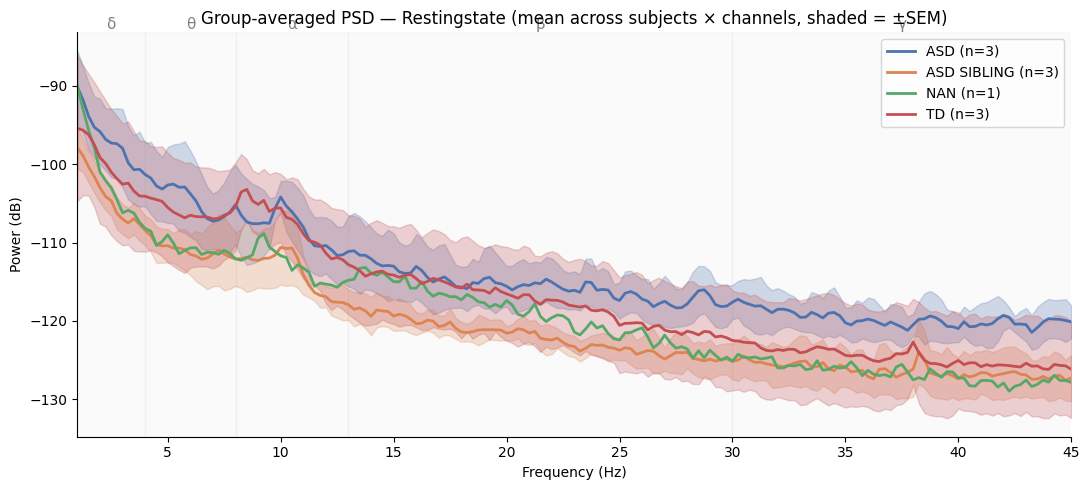

In [50]:
# 7.5 — Group-averaged PSD (mean across recordings × channels, ±SEM)
# Subjects may have different sampling rates → resample each PSD onto a
# common frequency grid before averaging.

if not any(group_data.values()):
    print("No recordings loaded — see the load cell output above.")
else:
    COMMON_FREQS = np.arange(1, 45.25, 0.25)

    def resample_psd(freqs, psd_1d):
        return np.interp(COMMON_FREQS, freqs, psd_1d)

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = dict(zip(group_data.keys(),
                       ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))

    for grp, recs in group_data.items():
        if not recs:
            continue
        # For each recording: average PSD across channels → 1D, then resample
        psds = np.stack([
            resample_psd(r["freqs"], r["psd_per_chan"].mean(axis=0))
            for r in recs
        ])  # shape: (n_subj, n_freqs)
        psds_db = 10 * np.log10(psds + 1e-30)
        mean = psds_db.mean(axis=0)
        sem = (psds_db.std(axis=0, ddof=1) / np.sqrt(len(recs))
               if len(recs) > 1 else np.zeros_like(mean))
        color = palette.get(grp)
        ax.plot(COMMON_FREQS, mean,
                label=f"{grp} (n={len(recs)})", color=color, linewidth=2)
        if len(recs) > 1:
            ax.fill_between(COMMON_FREQS, mean - sem, mean + sem,
                            color=color, alpha=0.25)

    # Shade canonical bands and label them at the top
    for lo, hi, name in [(1, 4, "δ"), (4, 8, "θ"), (8, 13, "α"),
                         (13, 30, "β"), (30, 45, "γ")]:
        ax.axvspan(lo, hi, alpha=0.04, color="gray")
        ax.text((lo + hi) / 2, 1.0, name,
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=11, color="gray")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)")
    ax.set_xlim(1, 45)
    ax.set_title(f"Group-averaged PSD — {TARGET_TASK} "
                 f"(mean across subjects × channels, shaded = ±SEM)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Clean up staged BDFs now that we're done with them
shutil.rmtree(SCRATCH, ignore_errors=True)
SCRATCH.mkdir(parents=True, exist_ok=True)


## 8. Spectral features across subjects (ASD vs control)

Now look across ~20–40 subjects to see if there's a visible group-level difference in band powers. **Don't** read too much into n=20 — the goal is sanity-check, not a paper figure. If groups look indistinguishable in this sample, that's normal and expected; the GNN's job is to find subtle multivariate structure.

In [ ]:
# ─── Band powers — streaming from OpenNeuro S3 (no local sync needed) ────────
import shutil
import boto3
from botocore import UNSIGNED
from botocore.config import Config

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
SCRATCH = Path("/tmp/eeg_scratch"); SCRATCH.mkdir(parents=True, exist_ok=True)
RAW_S3_BUCKET = "openneuro.org"
RAW_S3_PREFIX = "ds006780"

N_PER_GROUP = 5
TARGET_TASK = "Restingstate" if "Restingstate" in tasks else tasks[0]
print(f"Target task: {TARGET_TASK}")

def relative_band_power(psd_data, freqs, band):
    lo, hi = band
    mask = (freqs >= lo) & (freqs < hi)
    band_p  = psd_data[..., mask].sum(axis=-1)
    total_p = psd_data.sum(axis=-1)
    return band_p / np.where(total_p > 0, total_p, 1)

# ── ID matching ────────────────────────────────────────────────────────────
pid_col = next((c for c in participants.columns
                if c.lower() in ("participant_id", "participantid", "subject", "sub")),
               participants.columns[0])

def normalize(x):
    s = str(x).strip()
    return s[4:] if s.startswith("sub-") else s

participants_norm = participants.copy()
participants_norm["_sub_id"] = participants_norm[pid_col].apply(normalize)
bids_subjects_norm = {normalize(s) for s in subjects}
overlap = set(participants_norm["_sub_id"]) & bids_subjects_norm
print(f"Overlap (matched): {len(overlap)} subjects")
if not overlap:
    raise RuntimeError("No subject ID overlap. Check pid_col and subjects list.")

# ── Stage one recording from S3 to /tmp ───────────────────────────────────
def stage_from_s3(sub: str, task: str):
    """Download EEG file + sidecars for (sub, task). Returns local Path or None."""
    rel_dir = f"sub-{sub}/eeg"
    base = f"sub-{sub}_task-{task}"
    local_dir = SCRATCH / rel_dir
    local_dir.mkdir(parents=True, exist_ok=True)

    # List S3 to discover what files actually exist for this subject/task
    prefix = f"{RAW_S3_PREFIX}/{rel_dir}/{base}"
    try:
        resp = s3.list_objects_v2(Bucket=RAW_S3_BUCKET, Prefix=prefix)
    except Exception as e:
        print(f"    S3 list failed: {e}")
        return None
    keys = [obj["Key"] for obj in resp.get("Contents", [])]
    if not keys:
        return None

    # Download every file that matches (BDF or BrainVision triplet + sidecars)
    eeg_local = None
    for key in keys:
        fname = key.split("/")[-1]
        local_path = local_dir / fname
        if not local_path.exists():
            try:
                s3.download_file(RAW_S3_BUCKET, key, str(local_path))
            except Exception as e:
                print(f"    download {fname} failed: {e}")
                continue
        if fname.endswith(".bdf") or fname.endswith(".vhdr"):
            eeg_local = local_path
    return eeg_local

# ── Loop ─────────────────────────────────────────────────────────────────
records = []
for grp_name, grp_df in participants_norm.groupby(GROUP_COL):
    grp_subs = [s for s in grp_df["_sub_id"] if s in bids_subjects_norm][:N_PER_GROUP]
    print(f"\n[{grp_name}] processing {len(grp_subs)} subjects...")
    for i, sub in enumerate(grp_subs, 1):
        local_eeg = stage_from_s3(sub, TARGET_TASK)
        if local_eeg is None:
            print(f"  [{i}/{len(grp_subs)}] sub-{sub}: not found, skip")
            continue
        try:
            if local_eeg.suffix == ".bdf":
                raw_i = mne.io.read_raw_bdf(str(local_eeg), preload=True, verbose=False)
            else:
                raw_i = mne.io.read_raw_brainvision(str(local_eeg), preload=True, verbose=False)
            raw_i.pick("eeg")
            raw_i.filter(1, 45, verbose=False)
            psd = raw_i.compute_psd(fmin=1, fmax=45,
                                    n_fft=int(raw_i.info["sfreq"] * 4), verbose=False)
            psd_data, freqs = psd.get_data(), psd.freqs
            for band_name, band in BANDS.items():
                rp = relative_band_power(psd_data, freqs, band).mean()
                records.append({
                    "subject": sub, "group": str(grp_name),
                    "band": band_name.split()[0], "rel_power": float(rp),
                })
            print(f"  [{i}/{len(grp_subs)}] sub-{sub}: ok (sfreq={raw_i.info['sfreq']:.0f}Hz)")
        except Exception as e:
            print(f"  [{i}/{len(grp_subs)}] sub-{sub}: FAIL — {type(e).__name__}: {e}")
        finally:
            # Clean up /tmp so it doesn't fill up
            shutil.rmtree(local_eeg.parent, ignore_errors=True)

band_df = pd.DataFrame(records)
if band_df.empty:
    print("\n⚠️  No recordings processed. Check FAIL messages above.")
else:
    print(f"\n✅ Band powers for {band_df['subject'].nunique()} subjects "
          f"({len(band_df)} rows)")
    display(band_df.head())

Target task: Restingstate
Overlap (matched): 136 subjects

[ASD] processing 5 subjects...
  [1/5] sub-11025: ok (sfreq=512Hz)
  [2/5] sub-11038: ok (sfreq=512Hz)
  [3/5] sub-11049: ok (sfreq=512Hz)
  [4/5] sub-11055: ok (sfreq=512Hz)
  [5/5] sub-11057: ok (sfreq=512Hz)

[ASD SIBLING] processing 5 subjects...
  [1/5] sub-1501: ok (sfreq=512Hz)
  [2/5] sub-1502: ok (sfreq=512Hz)
  [3/5] sub-1507: ok (sfreq=512Hz)
  [4/5] sub-1513: ok (sfreq=512Hz)
  [5/5] sub-1514: ok (sfreq=512Hz)

[NAN] processing 1 subjects...
  [1/1] sub-11814: ok (sfreq=512Hz)

[TD] processing 5 subjects...
  [1/5] sub-10025: ok (sfreq=512Hz)
  [2/5] sub-10036: ok (sfreq=512Hz)


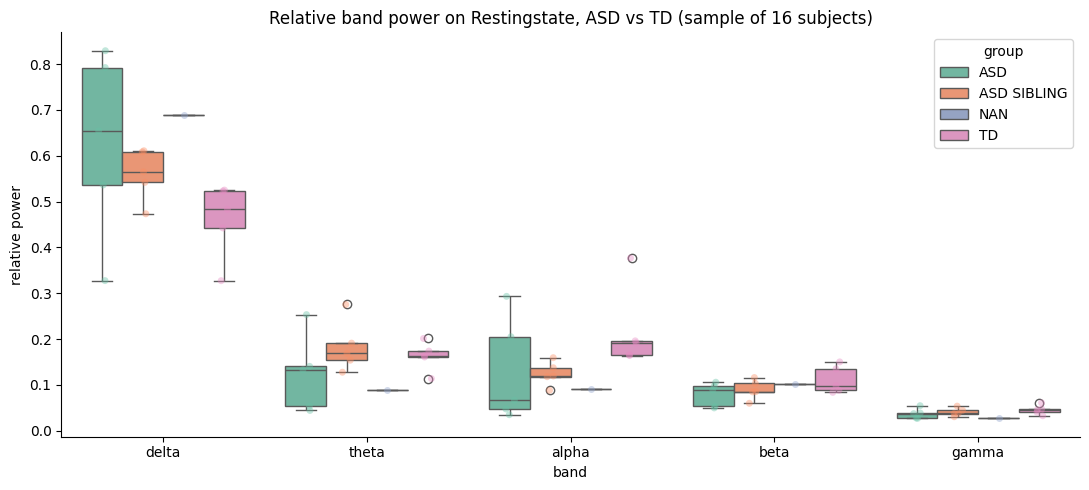

In [ ]:
if not band_df.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=band_df, x="band", y="rel_power", hue="group",
                ax=ax, order=["delta", "theta", "alpha", "beta", "gamma"])
    sns.stripplot(data=band_df, x="band", y="rel_power", hue="group",
                  order=["delta", "theta", "alpha", "beta", "gamma"],
                  dodge=True, alpha=0.4, ax=ax, legend=False)
    ax.set_title(f"Relative band power on {TARGET_TASK}, ASD vs TD (sample of {band_df['subject'].nunique()} subjects)")
    ax.set_ylabel("relative power")
    plt.tight_layout(); plt.show()

**Reading these plots honestly:**

- A handful of subjects per group is **not enough** to claim a difference. Treat any apparent gap as "interesting, run the full set" — not "ASD has more theta."
- If the plots look essentially identical between groups, that's normal — group-level resting-state band power differences in ASD are small and inconsistent in the literature. **The connectivity story (PLV) is much stronger than the spectral-power story.** That's exactly why your GNN+PLV plan makes sense.
- Watch for subjects with *very* extreme values (one subject's gamma 5× higher than everyone else). Those are usually muscle artifact survivors that ICA didn't clean fully. Worth flagging as preprocessing failures.

**What you should see:**

- A symmetric matrix with the diagonal masked.
- Block structure following the head's spatial layout — neighbors phase-lock more than distant pairs (volume conduction + true short-range connectivity).
- For a GNN, this matrix is your **adjacency** (or edge weights). For a multi-band GNN, you stack one per band → a (5 × 64 × 64) tensor per recording.

**Watch out for volume conduction.** PLV inflates between nearby electrodes purely from the shared underlying source bleeding into both. If you want "true" connectivity, look at PLI (Phase Lag Index) or wPLI instead — they suppress zero-lag coupling. **Forward-looking suggestion:** compute *both* PLV and wPLI as features for your GNN; let the model decide which is more discriminative. Adds ~30% to feature compute, costs nothing at inference.

---

## 10. Quality summary from preprocessing & ICA - not compelete yet

You've already run preprocessing → ICA fit → ICA label → ICA apply. The logs from those stages are gold for understanding data quality. If you saved per-file logs (you should have), aggregate them here.

This cell assumes you have a CSV or JSON of per-file logs from the ICA stage with columns like `subject, task, n_components, n_rejected, n_eye, n_muscle, n_heart, n_other`. Adapt to your actual log schema.

In [ ]:
# Adjust this path to wherever your ICA logs live
ICA_LOG_PATH = Path.home() / "asd_eeg_pipeline" / "derivatives" / "logs" / "ica_summary.csv"

if ICA_LOG_PATH.exists():
    ica_log = pd.read_csv(ICA_LOG_PATH)
    print(f"Loaded {len(ica_log)} ICA records")
    ica_log.head()
else:
    print(f"ICA log not found at {ICA_LOG_PATH}")
    print("Skip this section, or update the path. Recommended log schema:")
    print("  subject, task, n_components_total, n_rejected,")
    print("  n_eye, n_muscle, n_heart, n_line_noise, n_other,")
    print("  variance_explained_kept, fit_converged")
    ica_log = pd.DataFrame()

ICA log not found at /Users/alirezafatemi/asd_eeg_pipeline/derivatives/logs/ica_summary.csv
Skip this section, or update the path. Recommended log schema:
  subject, task, n_components_total, n_rejected,
  n_eye, n_muscle, n_heart, n_line_noise, n_other,
  variance_explained_kept, fit_converged


In [ ]:
if not ica_log.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribution of components rejected
    ica_log["n_rejected"].hist(bins=20, ax=axes[0], color="#DD8452")
    axes[0].set_title("Components rejected per recording")
    axes[0].set_xlabel("# rejected"); axes[0].set_ylabel("count")

    # Per-task rejection breakdown
    if "task" in ica_log.columns:
        ica_log.groupby("task")["n_rejected"].mean().plot.bar(ax=axes[1], color="#4C72B0")
        axes[1].set_title("Mean # rejected components per task")
        axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout(); plt.show()

    # Flag suspicious recordings — outliers in component rejection
    threshold = ica_log["n_rejected"].quantile(0.95)
    flagged = ica_log[ica_log["n_rejected"] > threshold]
    print(f"\n{len(flagged)} recordings had > 95th-percentile components rejected ({threshold:.0f}+):")
    print(flagged[["subject", "task", "n_rejected"]].head(15))

**Things to flag:**

- **Many recordings rejecting >50% of components.** Either ICA didn't fit well (often because the recording was too short — Restingstate is ~60 s × 250 Hz = 15,000 samples, near ICA's lower bound), or the data is genuinely terrible. Inspect a few manually before keeping or discarding.
- **A recording rejecting zero components.** ICLabel rarely says "all clean" for kid EEG. Suspicious — likely an ICA fit failure where every component looked ambiguous.
- **Per-task systematic differences.** If motor recordings reject 3× more components than resting-state, that's expected (movement artifact). If FAST rejects way more than IC, that's worth investigating.

---

## 11. Forward-looking — what to do with what you've learned

**Immediate things to write down before moving on:**

1. **Class balance and demographics** — exact counts per (group × age × sex). Lock these in for stratified splitting.
2. **Sampling rate decision** — what target rate you'll commit to for the connectivity features. 500 Hz is a safe pick (covers gamma) and BIDS-pipeline-friendly.
3. **Task selection** — which paradigms make it into the GNN. My honest recommendation given everything in this notebook: **start with Restingstate alone**. Get the full pipeline working end-to-end on one task, then expand to ASSR (the strongest paradigm-specific ASD signal in the literature). Don't try to fuse all 7 tasks until single-task works.
4. **Subjects to exclude** — anyone flagged in the quality summary. Document the exclusion criteria *before* you look at classification accuracy, or you're cheating.
5. **EXG handling** — confirmed earlier: keep EXG1–4 as `misc` (likely mastoids), drop EXG5–8. Note this in your methods section.

**Choices coming up that this notebook should inform:**

| Decision | What this notebook told you |
|---|---|
| Epoch length | Resting-state durations from §5 |
| Frequency bands for GNN | Standard 5 bands fit; gamma needs sfreq ≥ 250 Hz |
| Graph adjacency definition | Either fixed (montage-based) or learned (PLV/wPLI matrix) |
| Number of nodes | 64 (BioSemi64); EXG → misc, drop status |
| Connectivity metric | Compute both PLV and wPLI; ablate later |
| Stratification | Group × age × sex (from §3) |

**One last honest note.** The path from EDA to a publishable GNN is long. Each stage you skip understanding now becomes a reviewer comment later. If anything in this notebook surprised you (a sampling rate you didn't expect, a group imbalance you didn't know about, a task you're missing), pause and reconcile with the earlier preprocessing/ICA stages before going further. Better to redo two stages now than retract a paper later.